In [2]:
import numpy as np
import pandas as pd 
import os

train_df = pd.read_csv("/kaggle/input/notebook72b6690318/train_data.csv")
test_df = pd.read_csv("/kaggle/input/notebook72b6690318/test_data.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Columns:", train_df.columns.tolist())

# actual dataset columns
core_numeric = [
    'duration_log', 'duration_min' ,'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
    'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'time_signature'
]

derived = ['energy_dance_ratio', 'acoustic_electronic', 'artist_encoded', 'artist_freq']

#one-hot columns
genre_cols = [c for c in train_df.columns if c.startswith('track_genre_')]

feature_list = [c for c in (core_numeric + derived) if c in train_df.columns] + genre_cols

print("Requested core features (present):", [c for c in core_numeric if c in train_df.columns])
print("Requested derived features (present):", [c for c in derived if c in train_df.columns])
print("Number of genre cols found:", len(genre_cols))
print("Total features to use:", len(feature_list))

Train shape: (125112, 132)
Test shape: (31278, 132)
Columns: ['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'duration_log', 'energy_dance_ratio', 'acoustic_electronic', 'artist_freq', 'track_genre_afrobeat', 'track_genre_alt-rock', 'track_genre_alternative', 'track_genre_ambient', 'track_genre_anime', 'track_genre_black-metal', 'track_genre_bluegrass', 'track_genre_blues', 'track_genre_brazil', 'track_genre_breakbeat', 'track_genre_british', 'track_genre_cantopop', 'track_genre_chicago-house', 'track_genre_children', 'track_genre_chill', 'track_genre_classical', 'track_genre_club', 'track_genre_comedy', 'track_genre_country', 'track_genre_dance', 'track_genre_dancehall', 'track_genre_death-metal', 'track_genre_deep-house', 'track_genre_detroit-techno', 'track_genre_disco', 'track_genre_disney', 'track_genre_drum-and-bass', 'track_genre_dub', 'track_genr

# Building DNN Model

In [3]:
missing_train = [c for c in feature_list if c not in train_df.columns]
missing_test  = [c for c in feature_list if c not in test_df.columns]
print("Missing in train:", missing_train)
print("Missing in test:", missing_test)

# clipping extreme values - prevents very large values from destabilizing training
for df_ in (train_df, test_df):
    if 'energy_dance_ratio' in df_.columns:
        df_['energy_dance_ratio'] = df_['energy_dance_ratio'].clip(0, 10)
    if 'acoustic_electronic' in df_.columns:
        df_['acoustic_electronic'] = df_['acoustic_electronic'].clip(0, 10)

Missing in train: []
Missing in test: []


In [4]:
# Check for NaN
train_nan_count = train_df[feature_list].isnull().sum().sum()
test_nan_count  = test_df[feature_list].isnull().sum().sum()

train_inf_count = np.isinf(train_df[feature_list].values).sum()
test_inf_count  = np.isinf(test_df[feature_list].values).sum()

print("Train NaNs:", train_nan_count, "| Train Infs:", train_inf_count)
print("Test  NaNs:", test_nan_count,  "| Test  Infs:", test_inf_count)

Train NaNs: 0 | Train Infs: 0
Test  NaNs: 0 | Test  Infs: 0


In [ ]:
#!pip uninstall tensorflow keras protobuf -y

In [ ]:
#!pip install tensorflow==2.15.0 --force-reinstall

In [6]:
#!pip install protobuf==3.20.3 --force-reinstall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 7.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 3.20.3 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
tensorflow-me

In [8]:
import tensorflow as tf
from tensorflow import keras 

import matplotlib.pyplot as plt
import seaborn as sns
import keras_tuner as kt

from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, BatchNormalization, Input
from keras.optimizers import Adam, RMSprop
from keras.regularizers import l2, l1
from keras.utils import to_categorical, plot_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [9]:
X_train_full = train_df[feature_list].copy()
y_train_full = train_df['popularity'].astype(float).copy()

X_test = test_df[feature_list].copy()
y_test = test_df['popularity'].astype(float).copy()

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, stratify=None
)
print("Shapes of X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)

Shapes of X_train: (100089, 131) X_val: (25023, 131) X_test: (31278, 131)


In [11]:
scaler = StandardScaler()
scaler.fit(X_train)  # fit only on training data

X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, "scaler_train.joblib") # serialization -saves trained scaler object to a file on the disk-
 
# sanity check
print("Scaled shapes:", X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)
print("Any NaN after scaling (train/test)?", np.isnan(X_train_scaled).any(), np.isnan(X_test_scaled).any())


Scaled shapes: (100089, 131) (25023, 131) (31278, 131)
Any NaN after scaling (train/test)? False False


In [13]:
input_dim = X_train_scaled.shape[1]

model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dense(1, activation='linear')  # regression output
])

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',
    metrics=[tf.keras.metrics.MeanAbsoluteError()]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,001 (625.00 KB)

 Trainable params: 158,465 (619.00 KB)

 Non-trainable params: 1,536 (6.00 KB)

In [23]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True), # regularization method, prevents model from overfitting during training
    ModelCheckpoint("best_mlp_model.h5", monitor='val_loss', save_best_only=True) # periodically saves the model's weights
]

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose=2
)

Epoch 1/30


3128/3128 - 9s - 3ms/step - loss: 162.4519 - mean_absolute_error: 7.8396 - val_loss: 199.8085 - val_mean_absolute_error: 8.2527
Epoch 2/30
3128/3128 - 8s - 3ms/step - loss: 161.6928 - mean_absolute_error: 7.8302 - val_loss: 200.2952 - val_mean_absolute_error: 8.3552
Epoch 3/30
3128/3128 - 8s - 3ms/step - loss: 161.6926 - mean_absolute_error: 7.8418 - val_loss: 201.3812 - val_mean_absolute_error: 8.2351
Epoch 4/30
3128/3128 - 8s - 3ms/step - loss: 161.8684 - mean_absolute_error: 7.8112 - val_loss: 202.3404 - val_mean_absolute_error: 8.3918
Epoch 5/30
3128/3128 - 9s - 3ms/step - loss: 159.2823 - mean_absolute_error: 7.7645 - val_loss: 201.0038 - val_mean_absolute_error: 8.3529
Epoch 6/30
3128/3128 - 9s - 3ms/step - loss: 161.3552 - mean_absolute_error: 7.7943 - val_loss: 202.2017 - val_mean_absolute_error: 8.2630
Epoch 7/30


3128/3128 - 9s - 3ms/step - loss: 159.6335 - mean_absolute_error: 7.7722 - val_loss: 199.1042 - val_mean_absolute_error: 8.1856
Epoch 8/30
3128/3128 - 8s - 3ms/step - loss: 161.3838 - mean_absolute_error: 7.8010 - val_loss: 200.0104 - val_mean_absolute_error: 8.2004
Epoch 9/30


3128/3128 - 8s - 3ms/step - loss: 159.4307 - mean_absolute_error: 7.7533 - val_loss: 197.1820 - val_mean_absolute_error: 8.1138
Epoch 10/30
3128/3128 - 8s - 3ms/step - loss: 159.4415 - mean_absolute_error: 7.7484 - val_loss: 199.3617 - val_mean_absolute_error: 8.1374
Epoch 11/30


3128/3128 - 8s - 3ms/step - loss: 158.5663 - mean_absolute_error: 7.7158 - val_loss: 196.6594 - val_mean_absolute_error: 8.2095
Epoch 12/30
3128/3128 - 8s - 3ms/step - loss: 157.9860 - mean_absolute_error: 7.6973 - val_loss: 197.5417 - val_mean_absolute_error: 8.1257
Epoch 13/30
3128/3128 - 8s - 3ms/step - loss: 158.3983 - mean_absolute_error: 7.7271 - val_loss: 199.4077 - val_mean_absolute_error: 8.3636
Epoch 14/30
3128/3128 - 8s - 3ms/step - loss: 158.1827 - mean_absolute_error: 7.7201 - val_loss: 200.2840 - val_mean_absolute_error: 8.1756
Epoch 15/30
3128/3128 - 8s - 3ms/step - loss: 156.6278 - mean_absolute_error: 7.6735 - val_loss: 199.4476 - val_mean_absolute_error: 8.1796
Epoch 16/30


3128/3128 - 8s - 3ms/step - loss: 157.0023 - mean_absolute_error: 7.6648 - val_loss: 196.1923 - val_mean_absolute_error: 8.1442
Epoch 17/30
3128/3128 - 8s - 3ms/step - loss: 155.5610 - mean_absolute_error: 7.6330 - val_loss: 200.5872 - val_mean_absolute_error: 8.1663
Epoch 18/30
3128/3128 - 8s - 3ms/step - loss: 155.4554 - mean_absolute_error: 7.6340 - val_loss: 198.6778 - val_mean_absolute_error: 8.1914
Epoch 19/30
3128/3128 - 8s - 3ms/step - loss: 156.2515 - mean_absolute_error: 7.6393 - val_loss: 199.1769 - val_mean_absolute_error: 8.1999
Epoch 20/30
3128/3128 - 8s - 3ms/step - loss: 153.6314 - mean_absolute_error: 7.5895 - val_loss: 198.0480 - val_mean_absolute_error: 8.0197
Epoch 21/30
3128/3128 - 8s - 3ms/step - loss: 154.7077 - mean_absolute_error: 7.5992 - val_loss: 198.8788 - val_mean_absolute_error: 8.0342
Epoch 22/30
3128/3128 - 8s - 3ms/step - loss: 151.7565 - mean_absolute_error: 7.5336 - val_loss: 198.2105 - val_mean_absolute_error: 8.3040
Epoch 23/30


3128/3128 - 8s - 3ms/step - loss: 153.7385 - mean_absolute_error: 7.5708 - val_loss: 195.9940 - val_mean_absolute_error: 8.1017
Epoch 24/30
3128/3128 - 8s - 3ms/step - loss: 152.1419 - mean_absolute_error: 7.5229 - val_loss: 197.0125 - val_mean_absolute_error: 8.1702
Epoch 25/30


3128/3128 - 8s - 3ms/step - loss: 152.5978 - mean_absolute_error: 7.5377 - val_loss: 195.5880 - val_mean_absolute_error: 8.1122
Epoch 26/30
3128/3128 - 8s - 3ms/step - loss: 153.4662 - mean_absolute_error: 7.5550 - val_loss: 197.8503 - val_mean_absolute_error: 8.2572
Epoch 27/30
3128/3128 - 8s - 3ms/step - loss: 151.2277 - mean_absolute_error: 7.5018 - val_loss: 199.7267 - val_mean_absolute_error: 8.0816
Epoch 28/30
3128/3128 - 8s - 3ms/step - loss: 151.8439 - mean_absolute_error: 7.4738 - val_loss: 196.5117 - val_mean_absolute_error: 8.2405
Epoch 29/30


3128/3128 - 9s - 3ms/step - loss: 150.5102 - mean_absolute_error: 7.4861 - val_loss: 194.0116 - val_mean_absolute_error: 8.0269
Epoch 30/30
3128/3128 - 8s - 3ms/step - loss: 150.2641 - mean_absolute_error: 7.4608 - val_loss: 197.1005 - val_mean_absolute_error: 8.1005


In [24]:
best_model = tf.keras.models.load_model("best_mlp_model.h5", compile=False)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                   loss='mean_squared_error',
                   metrics=[tf.keras.metrics.MeanAbsoluteError()])

eval_results = best_model.evaluate(X_test_scaled, y_test, verbose=1)
print("Keras evaluate results (MSE, MAE):", eval_results)

y_pred_test = best_model.predict(X_test_scaled).ravel()
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
r2  = r2_score(y_test, y_pred_test)

print(f"\nFinal Test MSE: {mse:.4f}")
print(f"Final Test MAE: {mae:.4f}")
print(f"Final Test R2 : {r2:.4f}   ({100*r2:.1f}% like accuracy)")

978/978 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 200.6037 - mean_absolute_error: 8.1314
Keras evaluate results (MSE, MAE): [202.6826934814453, 8.152070999145508]
978/978 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Final Test MSE: 202.6827
Final Test MAE: 8.1521
Final Test R2 : 0.7400   (74.0% like accuracy)


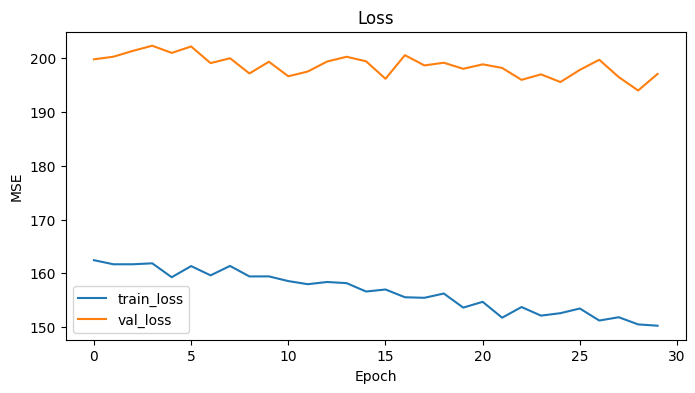

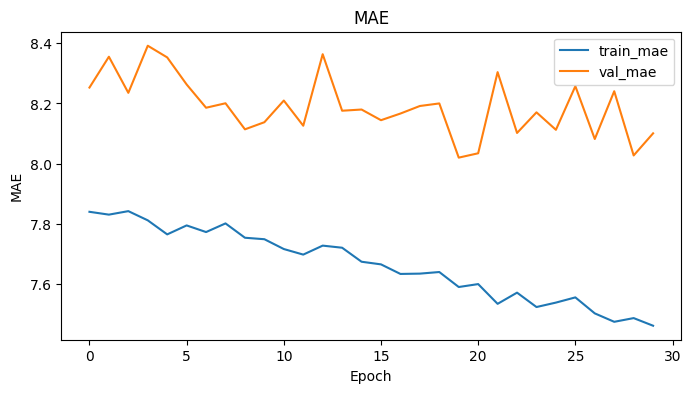

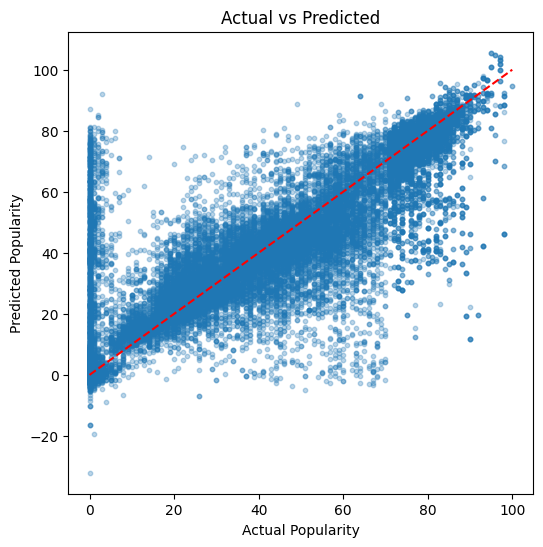

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


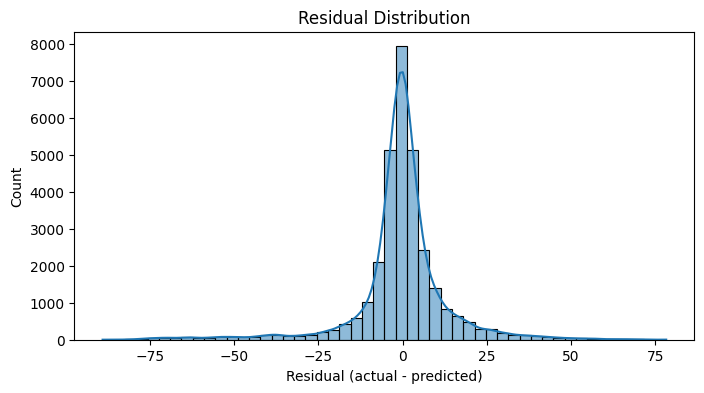

In [25]:
# Training/validation loss
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend(); plt.title('Loss'); plt.show()

# Training/validation MAE
plt.figure(figsize=(8,4))
plt.plot(history.history['mean_absolute_error'], label='train_mae')
plt.plot(history.history['val_mean_absolute_error'], label='val_mae')
plt.xlabel('Epoch'); plt.ylabel('MAE'); plt.legend(); plt.title('MAE'); plt.show()

# Actual vs Predicted (test)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.3, s=10)
plt.plot([0,100], [0,100], 'r--')
plt.xlabel('Actual Popularity'); plt.ylabel('Predicted Popularity'); plt.title('Actual vs Predicted'); plt.show()

# Residual histogram
residuals = y_test - y_pred_test
plt.figure(figsize=(8,4))
sns.histplot(residuals, bins=50, kde=True)
plt.xlabel('Residual (actual - predicted)'); plt.title('Residual Distribution'); plt.show()

# Autoencoders

In [26]:
X_auto = train_df[feature_list].values

scaler_ae = StandardScaler()
X_auto_scaled = scaler_ae.fit_transform(X_auto)

joblib.dump(scaler_ae, "scaler_autoencoder.joblib")

['scaler_autoencoder.joblib']

In [27]:
from tensorflow.keras import layers

input_dim = X_auto_scaled.shape[1]
latent_dim = 16   # start with 16; try 8, 32 later

# encoder
inputs = keras.Input(shape=(input_dim,))
x = layers.Dense(128, activation='relu')(inputs)
x = layers.Dense(64, activation='relu')(x)
latent = layers.Dense(latent_dim, activation='linear', name='latent_vector')(x) # bottleneck output

# decoder
x = layers.Dense(64, activation='relu')(latent)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(input_dim, activation='linear')(x) # final output reconstructs original D features

autoencoder = keras.Model(inputs, outputs, name='autoencoder_simple')
encoder = keras.Model(inputs, latent, name='encoder_simple')

autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mse')

history_ae = autoencoder.fit(
    X_auto_scaled, X_auto_scaled,
    epochs=50,
    batch_size=512,
    validation_split=0.1,
    verbose=2
)

Epoch 1/50
220/220 - 5s - 22ms/step - loss: 0.5815 - val_loss: 0.2388
Epoch 2/50
220/220 - 1s - 3ms/step - loss: 0.1584 - val_loss: 0.1137
Epoch 3/50
220/220 - 1s - 3ms/step - loss: 0.1047 - val_loss: 0.0994
Epoch 4/50
220/220 - 1s - 3ms/step - loss: 0.0975 - val_loss: 0.0946
Epoch 5/50
220/220 - 1s - 3ms/step - loss: 0.0928 - val_loss: 0.0900
Epoch 6/50
220/220 - 1s - 3ms/step - loss: 0.0880 - val_loss: 0.0848
Epoch 7/50
220/220 - 1s - 3ms/step - loss: 0.0839 - val_loss: 0.0818
Epoch 8/50
220/220 - 1s - 3ms/step - loss: 0.0810 - val_loss: 0.0798
Epoch 9/50
220/220 - 1s - 3ms/step - loss: 0.0785 - val_loss: 0.0773
Epoch 10/50
220/220 - 1s - 3ms/step - loss: 0.0765 - val_loss: 0.0750
Epoch 11/50
220/220 - 1s - 3ms/step - loss: 0.0752 - val_loss: 0.0741
Epoch 12/50
220/220 - 1s - 3ms/step - loss: 0.0739 - val_loss: 0.0725
Epoch 13/50
220/220 - 1s - 3ms/step - loss: 0.0725 - val_loss: 0.0717
Epoch 14/50
220/220 - 1s - 3ms/step - loss: 0.0716 - val_loss: 0.0708
Epoch 15/50
220/220 - 1s - 3

In [28]:
# evaluating reconstruction error and per-feature error
reconstructions = autoencoder.predict(X_auto_scaled)
recon_error_per_sample = np.mean(np.square(X_auto_scaled - reconstructions), axis=1)  # MSE per sample
print("Reconstruction MSE (mean):", recon_error_per_sample.mean())
print("Reconstruction MSE (median):", np.median(recon_error_per_sample))

# per-feature MSE
per_feature_mse = np.mean(np.square(X_auto_scaled - reconstructions), axis=0)
for name, mse_val in zip(feature_list, per_feature_mse):
    print(name, round(mse_val, 6))


3910/3910 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
Reconstruction MSE (mean): 0.05201476195623831
Reconstruction MSE (median): 0.042272032289734966
duration_log 0.060985
duration_ms 0.066412
explicit 0.253226
danceability 0.26253
energy 0.176906
key 0.931385
loudness 0.313295
mode 0.787349
speechiness 0.409543
acousticness 0.152885
instrumentalness 0.285799
liveness 0.690065
valence 0.388827
tempo 0.580533
time_signature 0.626019
energy_dance_ratio 0.116831
acoustic_electronic 0.130135
artist_freq 0.104638
track_genre_afrobeat 0.004062
track_genre_alt-rock 0.00387
track_genre_alternative 0.003817
track_genre_ambient 0.004776
track_genre_anime 0.004129
track_genre_black-metal 0.005558
track_genre_bluegrass 0.003967
track_genre_blues 0.003709
track_genre_brazil 0.003609
track_genre_breakbeat 0.003708
track_genre_british 0.004059
track_genre_cantopop 0.004513
track_genre_chicago-house 0.003398
track_genre_children 0.00426
track_genre_chill 0.004348
track_genre_classical 0.004202
track_genre_club 

In [29]:
# extracting latent embeddings for all samples and save
embeddings = encoder.predict(X_auto_scaled)  # shape (N, latent_dim)
print("Embeddings shape:", embeddings.shape)

# saving embeddings and feature names
np.save("autoencoder_embeddings.npy", embeddings)

# attaching embeddings to df
for i in range(embeddings.shape[1]):
    train_df[f'emb_{i}'] = embeddings[:, i]

# saveing df
train_df.to_csv("train_with_embeddings.csv", index=False)

3910/3910 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
Embeddings shape: (125112, 16)


In [32]:
autoencoder.save('autoencoder_model.h5') 
encoder.save('encoder_model.h5')          

# Cluster Embeddings 

In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print(f"\nEmbeddings shape: {embeddings.shape}")
print(f"Embeddings range: [{embeddings.min():.3f}, {embeddings.max():.3f}]")


Embeddings shape: (125112, 16)
Embeddings range: [-40.412, 55.495]


In [35]:
n_clusters = 12  # discover 12 audio-pattern-based micro-genres on how songs actually sound 
kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10,
    max_iter=300,
    verbose=0
)

In [36]:
clusters = kmeans.fit_predict(embeddings)

print(f"Found {n_clusters} clusters")

Found 12 clusters


In [37]:
# Quality Metrics 

silhouette = silhouette_score(embeddings, clusters)  # measures how well-separated clusters 
print(f"Silhouette Score: {silhouette:.4f}")
# Range: -1 to 1, higher = better separated clusters

# Cluster size distribution
print("\nCluster Distribution:")
unique_clusters, counts = np.unique(clusters, return_counts=True)
for cluster_id, count in zip(unique_clusters, counts):
    percentage = (count / len(clusters)) * 100
    print(f"  Cluster {cluster_id:2d}: {count:6d} tracks ({percentage:5.2f}%)")


Silhouette Score: 0.1646

Cluster Distribution:
  Cluster  0:   5853 tracks ( 4.68%)
  Cluster  1:   3985 tracks ( 3.19%)
  Cluster  2:  10635 tracks ( 8.50%)
  Cluster  3:  16481 tracks (13.17%)
  Cluster  4:  11639 tracks ( 9.30%)
  Cluster  5:  16494 tracks (13.18%)
  Cluster  6:  12071 tracks ( 9.65%)
  Cluster  7:   4891 tracks ( 3.91%)
  Cluster  8:   9834 tracks ( 7.86%)
  Cluster  9:   5048 tracks ( 4.03%)
  Cluster 10:  16792 tracks (13.42%)
  Cluster 11:  11389 tracks ( 9.10%)


In [39]:
# Add cluster labels to train_df
train_df['cluster'] = clusters

print(f"DataFrame shape: {train_df.shape}")

DataFrame shape: (125112, 149)


In [40]:
# audio features to analyze
audio_features = ['danceability', 'energy', 'acousticness', 
                  'instrumentalness', 'valence', 'tempo', 'popularity']

# mean values per cluster
cluster_profiles = train_df.groupby('cluster')[audio_features].mean()

print("\nCluster Profiles (mean values):")
print(cluster_profiles.round(2))

# defining characteristics of each cluster
print("\n" + "-"*70)
print("Top Defining Features Per Cluster")
print("-"*70)

for cluster_id in range(n_clusters):
    cluster_data = cluster_profiles.loc[cluster_id]
    
    # Find features that are notably high (>0.6) or low (<0.4) for normalized features
    high_features = cluster_data[(cluster_data > 0.6) & (cluster_data.index != 'tempo') & (cluster_data.index != 'popularity')]
    low_features = cluster_data[(cluster_data < 0.4) & (cluster_data.index != 'tempo') & (cluster_data.index != 'popularity')]
    
    print(f"\nCluster {cluster_id} ({counts[cluster_id]} tracks):")
    if len(high_features) > 0:
        print(f"  High: {', '.join([f'{f}={v:.2f}' for f, v in high_features.items()])}")
    if len(low_features) > 0:
        print(f"  Low:  {', '.join([f'{f}={v:.2f}' for f, v in low_features.items()])}")
    print(f"  Avg Popularity: {cluster_data['popularity']:.1f}")



Cluster Profiles (mean values):
         danceability  energy  acousticness  instrumentalness  valence  tempo  \
cluster                                                                         
0                0.32    0.08          0.04             -0.12     0.41  -0.07   
1                0.17    0.25         -0.25             -0.21     0.67   0.14   
2               -0.06    0.23         -0.14             -0.07     0.12   0.05   
3                0.05   -0.01          0.06             -0.29     0.12  -0.08   
4                0.27    0.24         -0.28             -0.10    -0.04   0.01   
5                0.14   -0.35          0.25             -0.18    -0.03  -0.05   
6               -0.34   -0.01         -0.05              0.32    -0.27   0.03   
7               -0.39    0.25         -0.30              0.43    -0.48   0.10   
8               -0.20    0.25         -0.29             -0.09    -0.22   0.13   
9               -0.05    0.34         -0.19              0.96    -0.16   0.1

In [41]:
# Get top 3 genres for each cluster
genre_cols = [c for c in train_df.columns if c.startswith('track_genre_')]

print("\nTop 3 Genres per Cluster:")
for cluster_id in range(n_clusters):
    cluster_mask = train_df['cluster'] == cluster_id
    cluster_genres = train_df.loc[cluster_mask, genre_cols].sum().sort_values(ascending=False).head(3)
    
    genre_names = [g.replace('track_genre_', '') for g in cluster_genres.index]
    print(f"\nCluster {cluster_id}:")
    for i, (genre, count) in enumerate(zip(genre_names, cluster_genres.values), 1):
        print(f"  {i}. {genre}: {int(count)} tracks")



Top 3 Genres per Cluster:

Cluster 0:
  1. latin: 12404 tracks
  2. blues: 12314 tracks
  3. indian: 10331 tracks

Cluster 1:
  1. disco: 12217 tracks
  2. punk-rock: 11768 tracks
  3. ska: 9940 tracks

Cluster 2:
  1. alt-rock: 14723 tracks
  2. punk: 12160 tracks
  3. j-pop: 11035 tracks

Cluster 3:
  1. pop: 17260 tracks
  2. dance: 16415 tracks
  3. metal: 14570 tracks

Cluster 4:
  1. house: 16559 tracks
  2. reggae: 12750 tracks
  3. progressive-house: 10740 tracks

Cluster 5:
  1. electro: 15950 tracks
  2. latino: 14332 tracks
  3. indie-pop: 14005 tracks

Cluster 6:
  1. rock: 15656 tracks
  2. indie: 15067 tracks
  3. soul: 12606 tracks

Cluster 7:
  1. dub: 10135 tracks
  2. heavy-metal: 10066 tracks
  3. cantopop: 10001 tracks

Cluster 8:
  1. k-pop: 15973 tracks
  2. alternative: 14952 tracks
  3. british: 11310 tracks

Cluster 9:
  1. deep-house: 9882 tracks
  2. afrobeat: 9811 tracks
  3. forro: 9491 tracks

Cluster 10:
  1. edm: 14370 tracks
  2. reggaeton: 13774 track

PCA explained variance: 24.90%


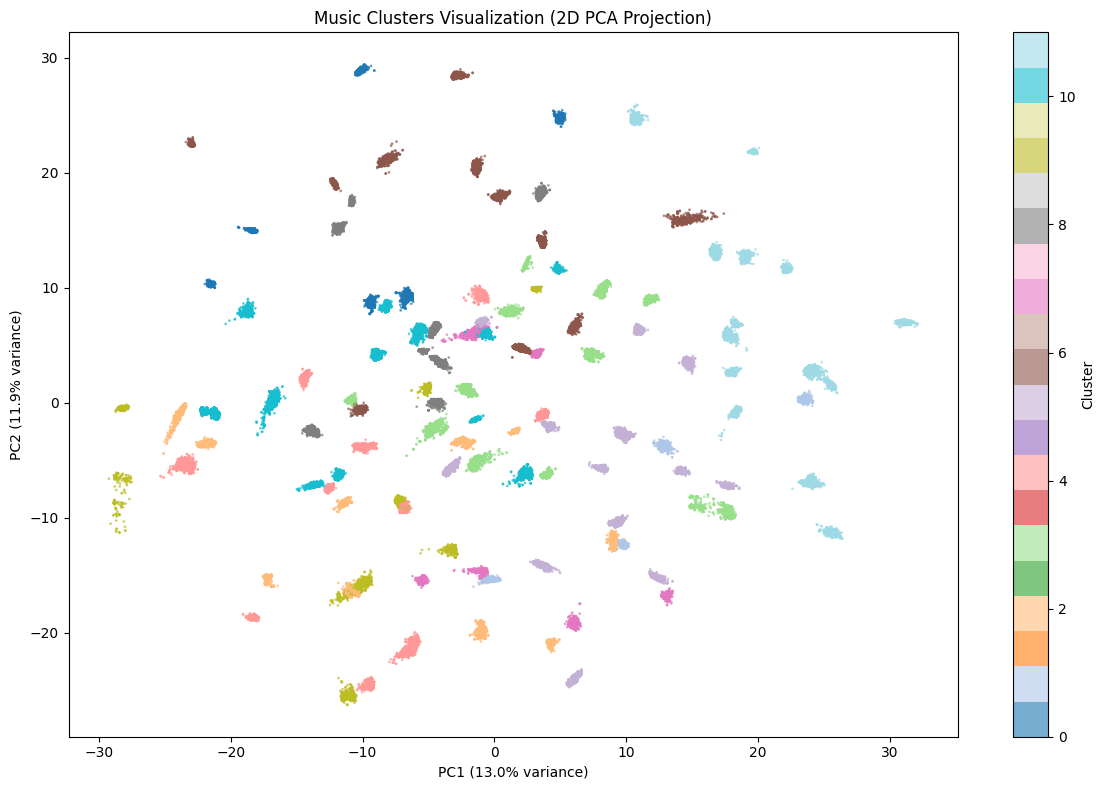

In [42]:
# Reduce embeddings to 2D for visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings)

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}")

# plotting clusters in 2D
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    embeddings_2d[:, 0], 
    embeddings_2d[:, 1], 
    c=clusters, 
    cmap='tab20', 
    alpha=0.6, 
    s=1
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Music Clusters Visualization (2D PCA Projection)')
plt.tight_layout()
plt.savefig('cluster_visualization.png', dpi=150, bbox_inches='tight')
plt.show()


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


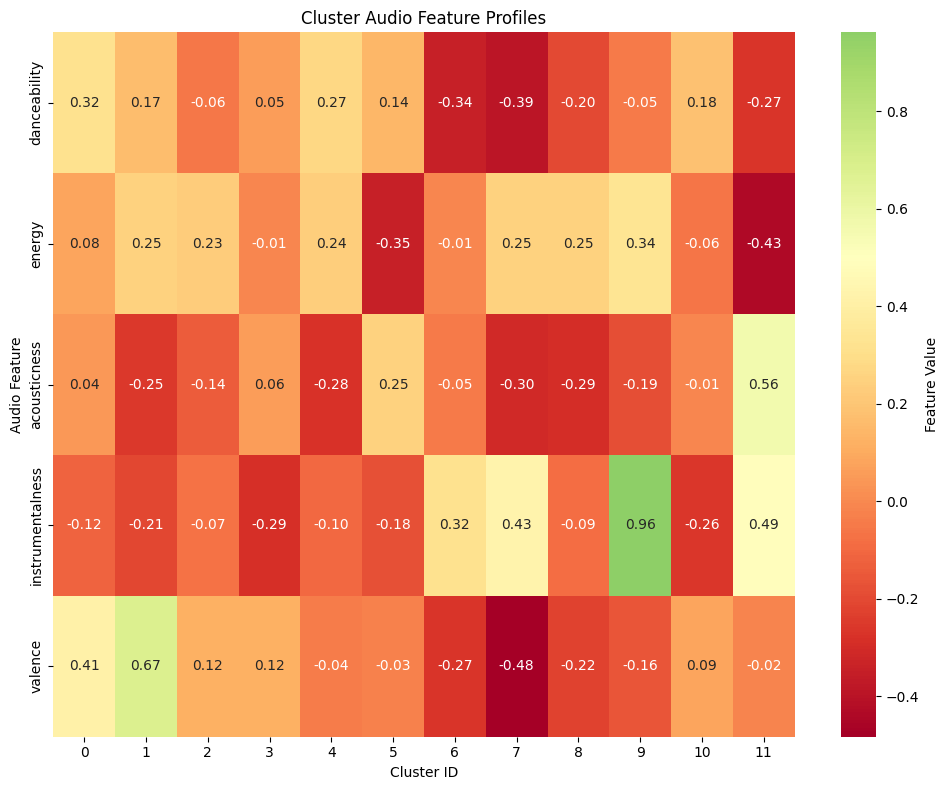

In [43]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    cluster_profiles[['danceability', 'energy', 'acousticness', 
                      'instrumentalness', 'valence']].T,
    cmap='RdYlGn',
    center=0.5,
    annot=True,
    fmt='.2f',
    cbar_kws={'label': 'Feature Value'}
)
plt.title('Cluster Audio Feature Profiles')
plt.xlabel('Cluster ID')
plt.ylabel('Audio Feature')
plt.tight_layout()
plt.savefig('cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [44]:
joblib.dump(kmeans, 'kmeans_model.joblib')
cluster_profiles.to_csv('cluster_profiles.csv')
train_df.to_csv('train_with_embeddings_and_clusters.csv', index=False)

In [45]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)
cluster_embeddings = ohe.fit_transform(clusters.reshape(-1, 1))

print(f"Cluster embeddings shape: {cluster_embeddings.shape}")
# 125112 tracks * 12 clusters 

np.save('cluster_embeddings.npy', cluster_embeddings)
joblib.dump(ohe, 'cluster_ohe.joblib')

Cluster embeddings shape: (125112, 12)


['cluster_ohe.joblib']

# Attention Mechanisms

In [49]:
class SimpleAttention(layers.Layer): 
    def __init__(self, **kwargs):
        super(SimpleAttention, self).__init__(**kwargs)
    
    def build(self, input_shape):
        self.feature_weights = self.add_weight(
            name='feature_importance',
            shape=(input_shape[-1],),  # 131 weights 1 for each features
            initializer='ones',
            trainable=True 
        )
    
    def call(self, inputs):
        attention = tf.nn.softmax(self.feature_weights)
        
        return inputs * attention

In [50]:
# input==> 131 features (audio features + genres + embeddings)
inputs = keras.Input(shape=(131,), name='features')

attended = SimpleAttention(name='attention')(inputs) #which features are important

x = layers.Dense(256, activation='relu')(attended)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32, activation='relu')(x)

#ppopularity prediction
outputs = layers.Dense(1, activation='linear')(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_52"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 131)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (SimpleAttention)     │ (None, 131)            │           131 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,188 (301.52 KB)

 Trainable params: 77,188 (301.52 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# Compile
model.compile(
    optimizer='adam',
    loss='mse', 
    metrics=['mae']
)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100, 
    batch_size=128,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
    ],
    verbose=2 
)

Epoch 1/100
782/782 - 9s - 11ms/step - loss: 694.6699 - mae: 20.1446 - val_loss: 528.5437 - val_mae: 17.1211
Epoch 2/100
782/782 - 2s - 3ms/step - loss: 561.2610 - mae: 17.8448 - val_loss: 540.2656 - val_mae: 17.9837
Epoch 3/100
782/782 - 2s - 3ms/step - loss: 554.1585 - mae: 17.6780 - val_loss: 519.6338 - val_mae: 16.8083
Epoch 4/100
782/782 - 2s - 3ms/step - loss: 544.5391 - mae: 17.4586 - val_loss: 509.6299 - val_mae: 16.7453
Epoch 5/100
782/782 - 2s - 3ms/step - loss: 534.3729 - mae: 17.2478 - val_loss: 500.0603 - val_mae: 16.5576
Epoch 6/100
782/782 - 2s - 3ms/step - loss: 523.0781 - mae: 16.9952 - val_loss: 493.0350 - val_mae: 16.3614
Epoch 7/100
782/782 - 2s - 3ms/step - loss: 514.4316 - mae: 16.8068 - val_loss: 482.8544 - val_mae: 16.0210
Epoch 8/100
782/782 - 2s - 3ms/step - loss: 504.7249 - mae: 16.5878 - val_loss: 474.9341 - val_mae: 15.8967
Epoch 9/100
782/782 - 2s - 3ms/step - loss: 495.2571 - mae: 16.3478 - val_loss: 476.7489 - val_mae: 16.3242
Epoch 10/100
782/782 - 2s -

In [52]:
y_pred_test = model.predict(X_test_scaled, verbose=0).flatten() #predictions

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae = mean_absolute_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

print(f"RMSE: {test_rmse:.2f}") #lower is better
print(f"MAE:  {test_mae:.2f}") 
print(f"R²:   {test_r2:.3f}") #closer to 1 is better


RMSE: 16.41
MAE:  10.68
R²:   0.655


In [53]:
attention_layer = model.get_layer('attention')

#learned weights
raw_weights = attention_layer.feature_weights.numpy() ##learned weights

importance_scores = tf.nn.softmax(raw_weights).numpy()

# Create a dataframe
importance_df = pd.DataFrame({
    'Feature': feature_list,
    'Importance': importance_scores,
    'Percentage': importance_scores * 100
}).sort_values('Importance', ascending=False)

print("TOP 15 MOST IMPORTANT FEATURES:")
print(importance_df.head(15)[['Feature', 'Percentage']].to_string(index=False))
print("___"*15)
print("\nBOTTOM 10 LEAST IMPORTANT FEATURES:")
print(importance_df.tail(10)[['Feature', 'Percentage']].to_string(index=False))


TOP 15 MOST IMPORTANT FEATURES:
           Feature  Percentage
       artist_freq    7.044806
          loudness    3.141434
       speechiness    2.794269
      danceability    2.524945
           valence    2.298309
            energy    2.244784
          liveness    2.120929
             tempo    2.116431
      duration_log    2.070684
               key    2.015434
      acousticness    2.010522
              mode    1.969863
energy_dance_ratio    1.850369
          explicit    1.802821
  instrumentalness    1.781716
_____________________________________________

BOTTOM 10 LEAST IMPORTANT FEATURES:
                   Feature  Percentage
         track_genre_sleep    0.246638
       track_genre_dubstep    0.244672
     track_genre_bluegrass    0.242803
       track_genre_new-age    0.238268
         track_genre_samba    0.231408
           track_genre_mpb    0.229837
track_genre_minimal-techno    0.229772
     track_genre_sertanejo    0.202983
         track_genre_forro    0.183174

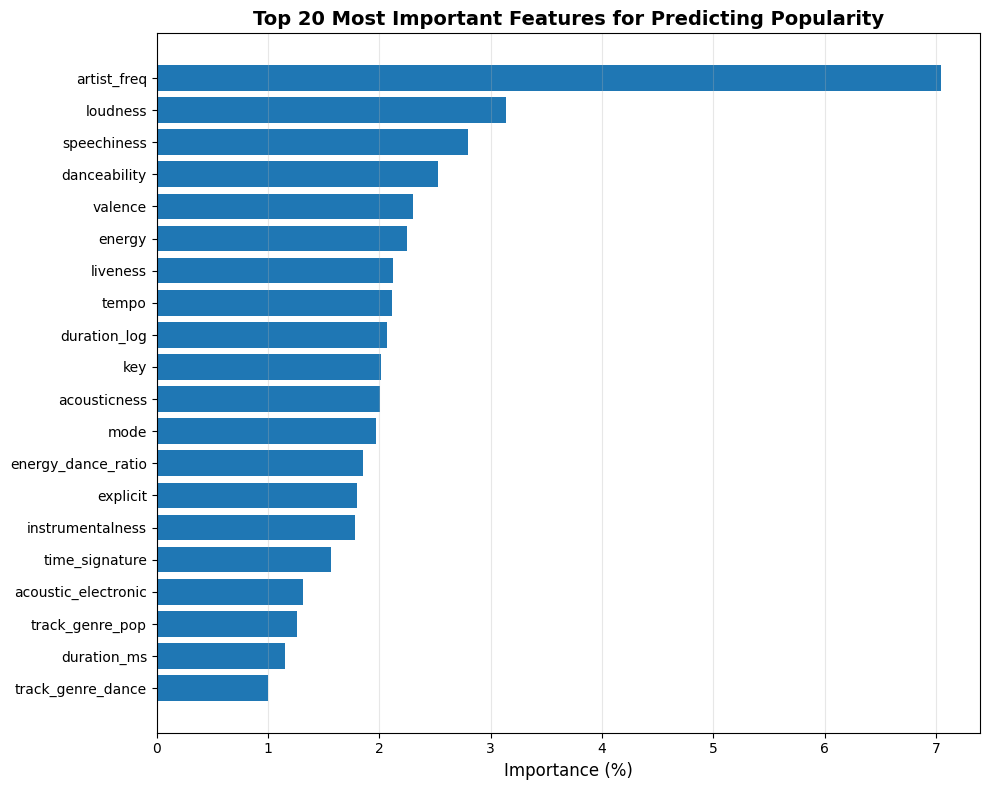

In [54]:
plt.figure(figsize=(10, 8))
top_20 = importance_df.head(20)

plt.barh(range(20), top_20['Percentage'])
plt.yticks(range(20), top_20['Feature'])
plt.xlabel('Importance (%)', fontsize=12)
plt.title('Top 20 Most Important Features for Predicting Popularity', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('attention_importance.png', dpi=150)
plt.show()

In [55]:
model.save('attention_model.h5')
importance_df.to_csv('feature_importance.csv', index=False)

# Compare against traditional audio analysis methods

1. Linear Regression (simplest model)

In [56]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_pred_test = lr_model.predict(X_test_scaled)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred_test))
lr_mae = mean_absolute_error(y_test, lr_pred_test)
lr_r2 = r2_score(y_test, lr_pred_test)

print(f"RMSE: {lr_rmse:.4f}")
print(f"MAE:  {lr_mae:.4f}")
print(f"R²:   {lr_r2:.4f}")


RMSE: 23.2367
MAE:  17.3297
R²:   0.3075


 2. Random Forest (popular traditional ML)

In [57]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,# 100 trees
    max_depth=20,       
    random_state=42,
    n_jobs=-1,     
    verbose=0
)
rf_model.fit(X_train_scaled, y_train)

rf_pred_test = rf_model.predict(X_test_scaled)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred_test))
rf_mae = mean_absolute_error(y_test, rf_pred_test)
rf_r2 = r2_score(y_test, rf_pred_test)

print(f"RMSE: {rf_rmse:.4f}")
print(f"MAE:  {rf_mae:.4f}")
print(f"R²:   {rf_r2:.4f}")

RMSE: 17.3596
MAE:  12.5570
R²:   0.6135


3. XGBoost (state-of-the-art traditional ML)

In [58]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,          
    learning_rate=0.05, #slower learning = better results
    max_depth=6,       
    random_state=42,
    tree_method='hist', 
    verbosity=0
)
xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)

xgb_pred_test = xgb_model.predict(X_test_scaled)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred_test))
xgb_mae = mean_absolute_error(y_test, xgb_pred_test)
xgb_r2 = r2_score(y_test, xgb_pred_test)

print(f"RMSE: {xgb_rmse:.4f}")
print(f"MAE:  {xgb_mae:.4f}")
print(f"R²:   {xgb_r2:.4f}")

RMSE: 21.3474
MAE:  16.5165
R²:   0.4155


4. Attention DNN (deep learning)

In [59]:
dnn_rmse = test_rmse 
dnn_mae = test_mae   
dnn_r2 = test_r2    

print(f"RMSE: {dnn_rmse:.4f}")
print(f"MAE:  {dnn_mae:.4f}")
print(f"R²:   {dnn_r2:.4f}")

RMSE: 16.4076
MAE:  10.6826
R²:   0.6547


In [60]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost', 'Attention DNN'],
    'Type': ['Traditional', 'Traditional', 'Traditional', 'Deep Learning'],
    'RMSE': [lr_rmse, rf_rmse, xgb_rmse, dnn_rmse],
    'MAE': [lr_mae, rf_mae, xgb_mae, dnn_mae],
    'R²': [lr_r2, rf_r2, xgb_r2, dnn_r2]
})

comparison = comparison.sort_values('RMSE')
print("\n" + comparison.to_string(index=False))

best_model = comparison.iloc[0]
print(f"Best Model: {best_model['Model']}")
print(f"Best RMSE: {best_model['RMSE']:.4f}")


            Model          Type      RMSE       MAE       R²
    Attention DNN Deep Learning 16.407604 10.682603 0.654707
    Random Forest   Traditional 17.359563 12.557012 0.613477
          XGBoost   Traditional 21.347433 16.516467 0.415494
Linear Regression   Traditional 23.236685 17.329725 0.307458
Best Model: Attention DNN
Best RMSE: 16.4076


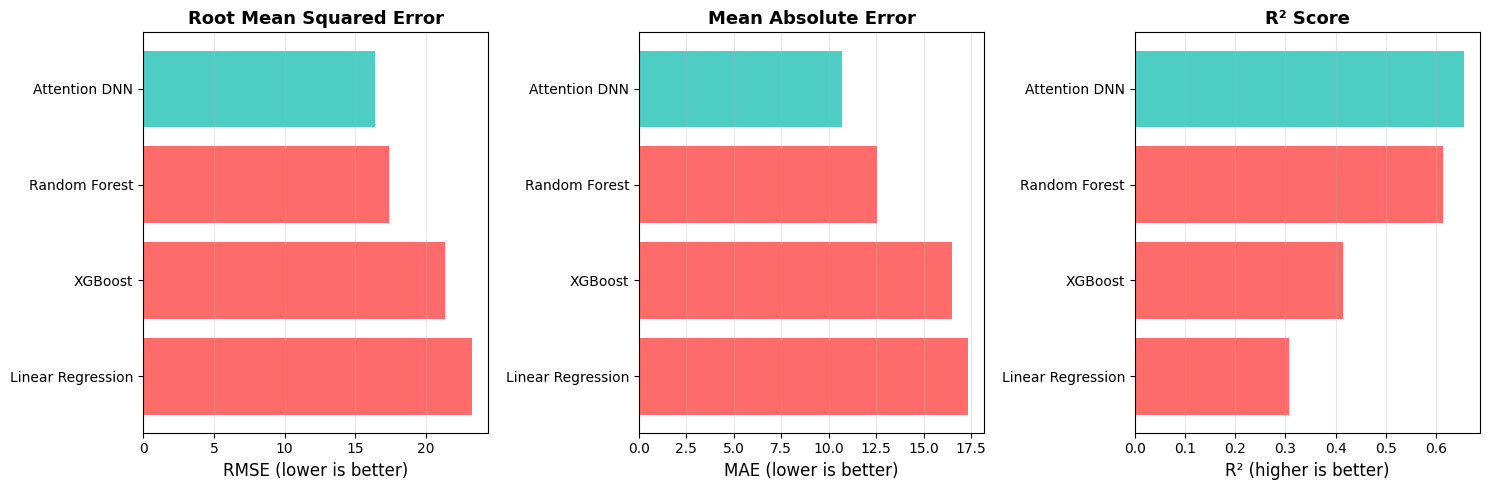

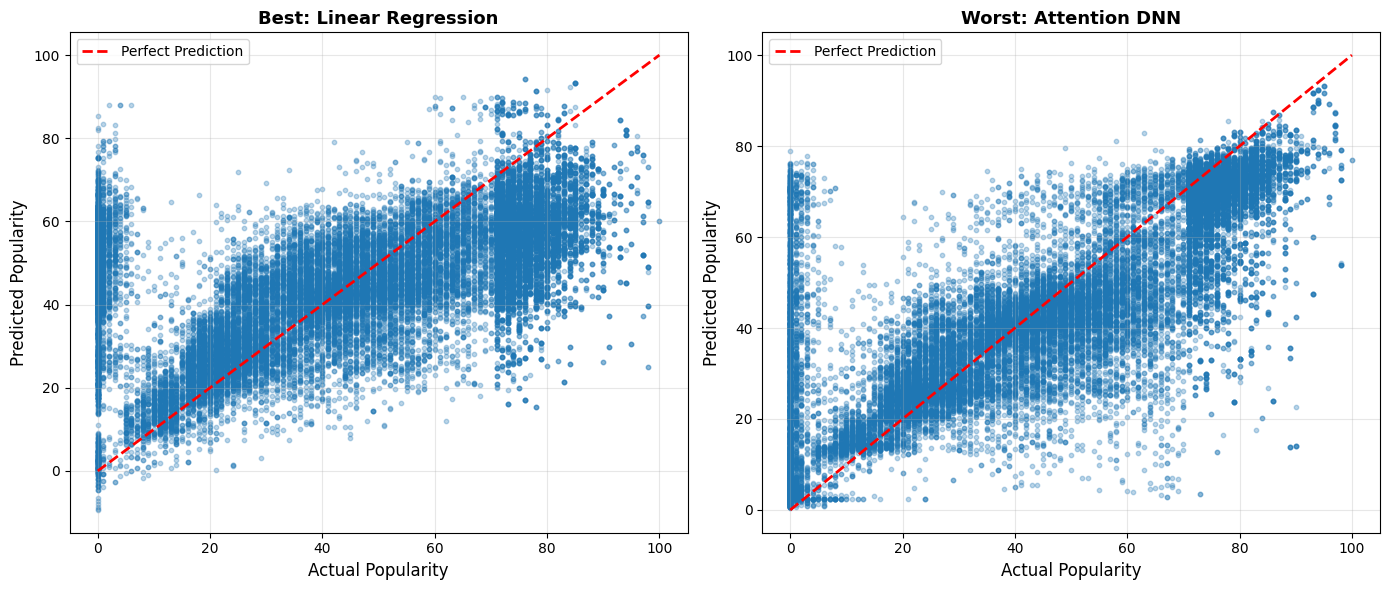

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# RMSE
colors = ['#ff6b6b' if t == 'Traditional' else '#4ecdc4' for t in comparison['Type']]
axes[0].barh(comparison['Model'], comparison['RMSE'], color=colors)
axes[0].set_xlabel('RMSE (lower is better)', fontsize=12)
axes[0].set_title('Root Mean Squared Error', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# MAE
axes[1].barh(comparison['Model'], comparison['MAE'], color=colors)
axes[1].set_xlabel('MAE (lower is better)', fontsize=12)
axes[1].set_title('Mean Absolute Error', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

# R^2
axes[2].barh(comparison['Model'], comparison['R²'], color=colors)
axes[2].set_xlabel('R² (higher is better)', fontsize=12)
axes[2].set_title('R² Score', fontsize=13, fontweight='bold')
axes[2].invert_yaxis()
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

best_idx = comparison['RMSE'].idxmin()
best_name = comparison.iloc[best_idx]['Model']
if best_name == 'Linear Regression':
    best_pred = lr_pred_test
elif best_name == 'Random Forest':
    best_pred = rf_pred_test
elif best_name == 'XGBoost':
    best_pred = xgb_pred_test
else:
    best_pred = y_pred_test

axes[0].scatter(y_test, best_pred, alpha=0.3, s=10)
axes[0].plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Popularity', fontsize=12)
axes[0].set_ylabel('Predicted Popularity', fontsize=12)
axes[0].set_title(f'Best: {best_name}', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

worst_idx = comparison['RMSE'].idxmax()
worst_name = comparison.iloc[worst_idx]['Model']
if worst_name == 'Linear Regression':
    worst_pred = lr_pred_test
elif worst_name == 'Random Forest':
    worst_pred = rf_pred_test
elif worst_name == 'XGBoost':
    worst_pred = xgb_pred_test
else:
    worst_pred = y_pred_test

axes[1].scatter(y_test, worst_pred, alpha=0.3, s=10)
axes[1].plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Popularity', fontsize=12)
axes[1].set_ylabel('Predicted Popularity', fontsize=12)
axes[1].set_title(f'Worst: {worst_name}', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('predictions_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
